In [1]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.patches as mpatches
from utils import *
import matplotlib.colors as mcolors



In [2]:
def visualize(dimensions, problems, algorithms, runs, line_plot_y=False, plot_y=False, data_dir=None, save=False):
    if data_dir is None:
        data_dir=f'data/clustering_features_x_only'
    for dimension in dimensions:
        directory=f'{data_dir}/cluster_distributions/dim_{dimension}'
        for problem in problems:
            cluster_centers=pd.read_csv(f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv',index_col=0)
            
            print(cluster_centers)
            cluster_centers = {index: ', '.join([ str(round(row[c],2)) for c in row.keys()]) for index, row in cluster_centers.iterrows()}
            print(cluster_centers)
            solutions=pd.read_parquet(f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')
            file_loc=f'{directory}/{problem}.csv'
            if os.path.isfile(file_loc):
                df=pd.read_csv(file_loc,index_col=[0,1,2])
                df.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in df.columns]
                for a in algorithms:
                    for run in runs:
                        print(problem,a,run)

                        s = solutions.query('algorithm==@a and run==@run').groupby(['iteration', 'cluster'])['scaled_raw_y']
                        s_min=s.min().cummin().to_frame().reset_index()
                        print(s_min)
                        #s_mean=s.mean().to_frame().reset_index()
                        #s_stats = pd.concat([s_min.assign(stat='min'), s_mean.assign(stat='mean')])
                        
                        # Create a figure with subplots
                        fig, axes = plt.subplots(1, 2 if plot_y else 1, figsize=(15 if plot_y else 7, int(s_min['iteration'].max() / 3 )), squeeze=False)
                        axes=axes[0]
                        print(axes[0])

                        # Plot the line plot on the first axis

                        if plot_y:
                            if line_plot_y:
                                sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y', hue='cluster', style='cluster',palette='tab10',markers=True, dashes=False, ax=axes[1])
                                axes[1].set_title('Minimum scaled y per cluster and iteration')
                                axes[1].set_xlabel('Iteration')
                                axes[1].set_ylabel('Scaled Raw Y')
                            else:
                                s_min_pivoted=s_min.pivot(index='iteration', columns='cluster', values='scaled_raw_y')
                                s_min_pivoted.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in s_min_pivoted.columns]
                                sns.heatmap(s_min_pivoted, annot=True,ax=axes[1],cmap="YlGnBu", fmt=".3f",norm=mcolors.LogNorm())
                        
                        # Plot the heatmap on the second axis
                        sns.heatmap(df.loc[a, run].replace(0,np.nan), annot=True, ax=axes[0],cmap='YlGnBu')

                        
                        # Adjust layout
                        plt.tight_layout()
                        if save:
                            file_name=f'{problem}_{a}_run_{run}.pdf'
                            plt.savefig('figures_clustering_new/{file_name}',bbox_inches=0)
                        # Show the combined plot
                        plt.show()
                        
                        '''plt.figure()
                        sns.lineplot(s,x='iteration',y='scaled_raw_y', hue='cluster',palette='tab10')
                        plt.show()
                        
                        plt.figure(figsize=(5,dimension*2))
                        sns.heatmap(df.loc[a,run].T,annot=True)
                        plt.show()'''

In [3]:
def visualize_multi(dimensions, problems, algorithms, runs, line_plot_y=False, plot_y=False, data_dir=None, save=False, popsize=50):
    if data_dir is None:
        data_dir=f'data/clustering_features_x_only'
    for dimension in dimensions:
        directory=f'{data_dir}/cluster_distributions/dim_{dimension}'
        for problem in problems:
            cluster_centers=pd.read_csv(f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv',index_col=0)
            print(cluster_centers)
            cluster_count=cluster_centers.shape[0]
            cluster_centers = {index: ', '.join([ str(round(row[c],2)) for c in row.keys()]) for index, row in cluster_centers.iterrows()}
            print(cluster_centers)
            solutions=pd.read_parquet(f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')
            file_loc=f'{directory}/{problem}.csv'
            if os.path.isfile(file_loc):
                df=pd.read_csv(file_loc,index_col=[0,1,2])
                df.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in df.columns]
                fig, all_axes = plt.subplots(len(algorithms), 2 if plot_y else 1, figsize=(cluster_count if plot_y else 10, 3*dimension * len(algorithms)), squeeze=False, sharex=True)
                for a_index, a in enumerate(algorithms):
                    for run in runs:
                        print(problem,a,run)

                        s = solutions.query('algorithm==@a and run==@run').groupby(['iteration', 'cluster'])['scaled_raw_y']
                        s_min=s.min().to_frame().reset_index()
                        #s_mean=s.mean().to_frame().reset_index()
                        #s_stats = pd.concat([s_min.assign(stat='min'), s_mean.assign(stat='mean')])
                        
                        # Create a figure with subplots
                        #fig, axes = plt.subplots(1, 2 if plot_y else 1, figsize=(15 if plot_y else 7, int(s_min['iteration'].max() / 3 )), squeeze=False)
                        axes=all_axes[a_index]

                        # Plot the line plot on the first axis
                        axes[0].set_title(f'Algorithm: {a}; Run: {run}')
                        if plot_y:
                            if line_plot_y:
                                sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y', hue='cluster', style='cluster',palette='tab10',markers=True, dashes=False, ax=axes[1])
                                axes[1].set_title('Minimum scaled y per cluster and iteration')
                                axes[1].set_xlabel('Iteration')
                                axes[1].set_ylabel('Scaled Raw Y')
                            else:
                                s_min_pivoted=s_min.pivot(index='iteration', columns='cluster', values='scaled_raw_y')
                                s_min_pivoted.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in s_min_pivoted.columns]
                                sns.heatmap(s_min_pivoted, annot=True,ax=axes[1], vmin=0, vmax=1)
                        
                        # Plot the heatmap on the second axis
                        sns.heatmap(df.loc[a, run].replace(0,np.nan), annot=True, ax=axes[0], vmin=0, vmax=popsize,cmap='YlGnBu')

                        
                        # Adjust layout
                
                plt.tight_layout()
                plt.margins(0, tight=True)
                if save:
                    file_name=f"{data_dir.split('/')[-1]}_{problem}_{'+'.join(algorithms)}_run_{'+'.join([str(r) for r in runs])}.pdf"
                    plt.savefig(f'figures_clustering_new/{file_name}',bbox_inches='tight', pad_inches=0)
                # Show the combined plot
                plt.show()

    scaled_x0  scaled_x1
0   -3.421774  -3.256977
1   -1.840814  -1.003781
2   -2.227226   1.151469
3   -1.532356  -4.814320
4   -2.228299  -3.167990
..        ...        ...
59   1.804654  -2.699458
60  -0.931766  -0.229111
61  -4.673708  -2.196254
62  -4.154952   3.035079
63  -2.630608  -0.748294

[64 rows x 2 columns]
{0: '-3.42, -3.26', 1: '-1.84, -1.0', 2: '-2.23, 1.15', 3: '-1.53, -4.81', 4: '-2.23, -3.17', 5: '-2.28, -0.23', 6: '1.64, 1.71', 7: '-1.13, -2.0', 8: '-2.26, 3.41', 9: '0.93, -1.68', 10: '1.86, -4.39', 11: '-3.38, 1.87', 12: '-3.02, -0.1', 13: '-1.2, 0.67', 14: '-1.95, -1.89', 15: '-4.75, 4.46', 16: '-1.08, -3.7', 17: '-1.23, -2.82', 18: '-0.95, -1.27', 19: '-2.11, 0.36', 20: '3.52, -3.07', 21: '-2.7, -1.58', 22: '3.55, 1.17', 23: '-4.78, -0.48', 24: '-2.15, -0.48', 25: '-2.77, 2.19', 26: '-2.83, 0.87', 27: '0.36, -4.65', 28: '-4.76, -4.67', 29: '-1.57, -0.37', 30: '1.99, -0.52', 31: '-1.1, 2.12', 32: '3.21, 3.85', 33: '-3.63, 0.73', 34: '0.54, -3.13', 35: '-1.47, -1.

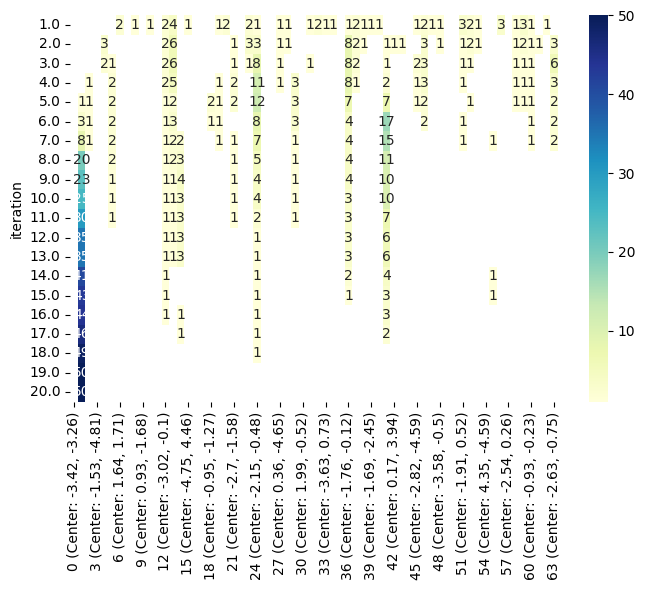

F15_I3 HI_WOA 2
     iteration  cluster  scaled_raw_y
0          1.0        4  6.273945e-03
1          1.0        5  4.756305e-03
2          1.0        6  4.756305e-03
3          1.0        7  4.756305e-03
4          1.0        8  4.756305e-03
..         ...      ...           ...
226       18.0       55  1.215737e-06
227       19.0        1  4.108353e-07
228       19.0       55  4.108353e-07
229       20.0        1  1.076122e-07
230       20.0       55  1.076122e-07

[231 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


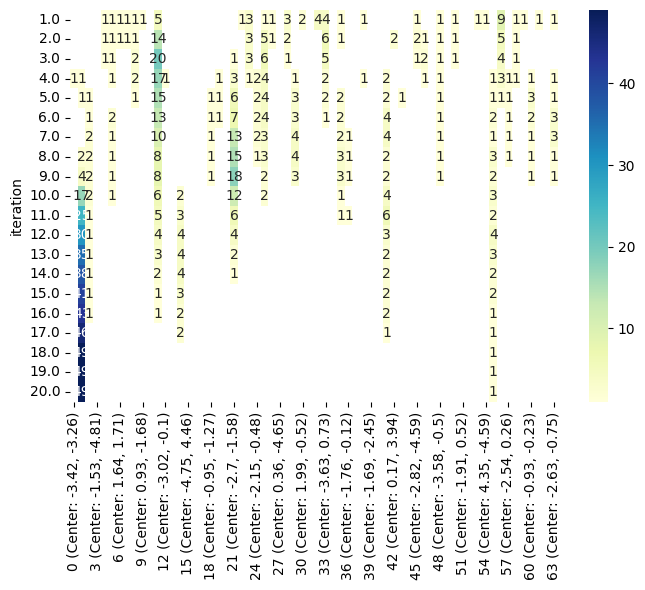

F15_I3 HI_WOA 3
     iteration  cluster  scaled_raw_y
0          1.0        0      0.011246
1          1.0        2      0.004880
2          1.0        3      0.004880
3          1.0        5      0.003708
4          1.0        6      0.003708
..         ...      ...           ...
164       17.0       24      0.000182
165       17.0       36      0.000182
166       18.0       36      0.000182
167       19.0       36      0.000182
168       20.0       36      0.000182

[169 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


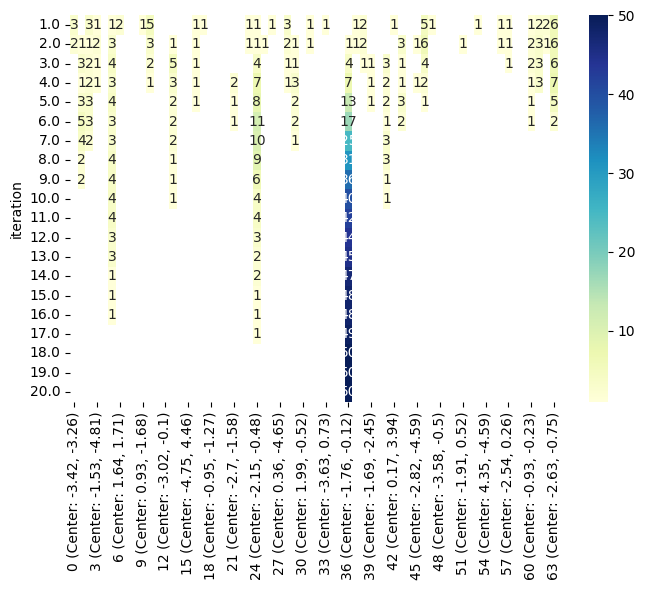

F15_I3 HI_WOA 4
     iteration  cluster  scaled_raw_y
0          1.0        2      0.005689
1          1.0        3      0.005689
2          1.0        4      0.005689
3          1.0        6      0.005689
4          1.0        7      0.004713
..         ...      ...           ...
156       17.0       55      0.000195
157       18.0       14      0.000195
158       18.0       55      0.000195
159       19.0       14      0.000194
160       20.0       14      0.000193

[161 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


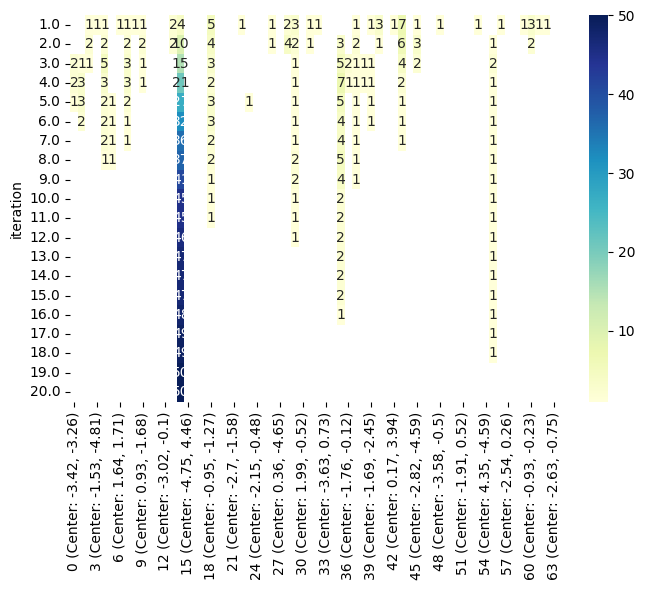

F15_I3 HI_WOA 5
     iteration  cluster  scaled_raw_y
0          1.0        0  1.076195e-02
1          1.0        2  2.655219e-03
2          1.0        3  2.655219e-03
3          1.0        4  2.655219e-03
4          1.0        5  2.655219e-03
..         ...      ...           ...
190       17.0       41  2.284802e-07
191       18.0        1  2.067906e-07
192       18.0       55  2.067906e-07
193       19.0        1  1.908744e-07
194       20.0        1  1.483657e-07

[195 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


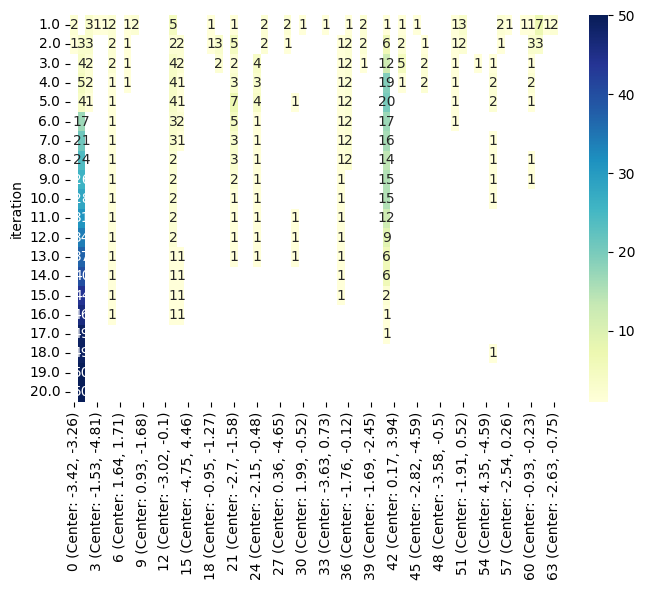

F15_I3 OriginalWOA 1
     iteration  cluster  scaled_raw_y
0          1.0        0      0.009923
1          1.0        1      0.004099
2          1.0        3      0.004099
3          1.0        4      0.003649
4          1.0        6      0.003649
..         ...      ...           ...
205       19.0       14      0.000002
206       19.0       18      0.000002
207       19.0       36      0.000002
208       20.0        1      0.000002
209       20.0       36      0.000002

[210 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


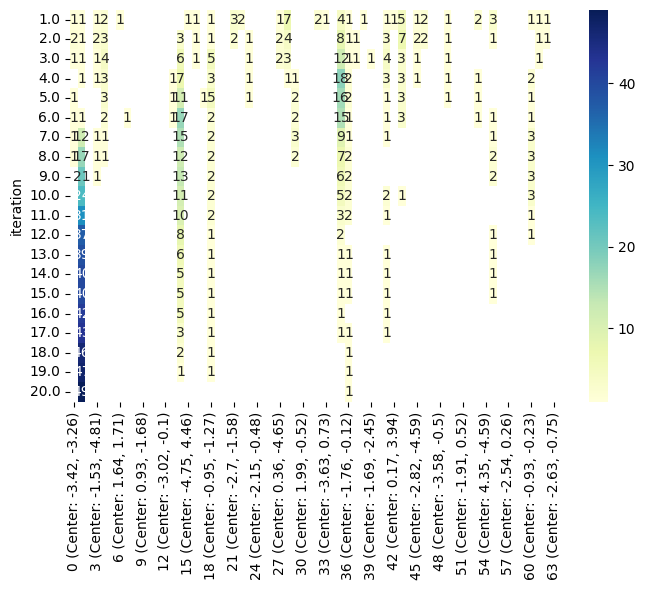

F15_I3 OriginalWOA 2
     iteration  cluster  scaled_raw_y
0          1.0        5      0.003250
1          1.0        6      0.003250
2          1.0        7      0.003250
3          1.0       10      0.003250
4          1.0       11      0.003250
..         ...      ...           ...
217       19.0       19      0.000732
218       19.0       24      0.000732
219       19.0       51      0.000731
220       20.0       24      0.000731
221       20.0       51      0.000730

[222 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


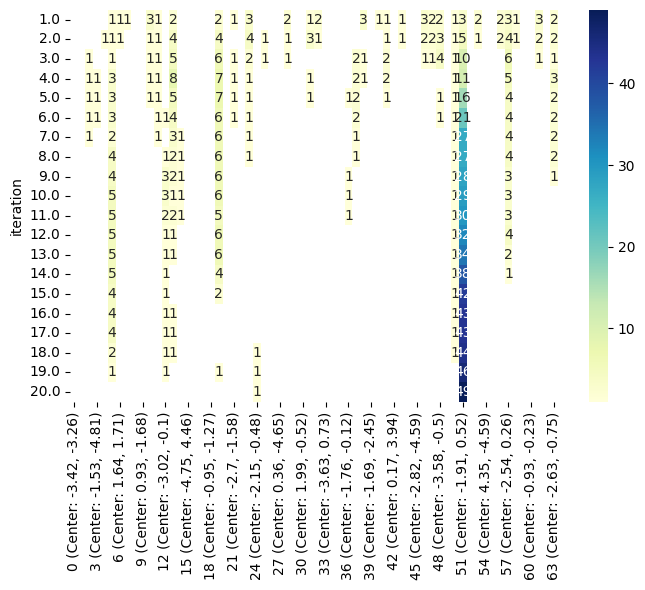

F15_I3 OriginalWOA 3
     iteration  cluster  scaled_raw_y
0          1.0        2      0.005535
1          1.0        7      0.003610
2          1.0        8      0.003610
3          1.0        9      0.003610
4          1.0       10      0.003610
..         ...      ...           ...
210       19.0       44      0.002432
211       20.0        7      0.002432
212       20.0       11      0.002432
213       20.0       12      0.002432
214       20.0       25      0.002431

[215 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


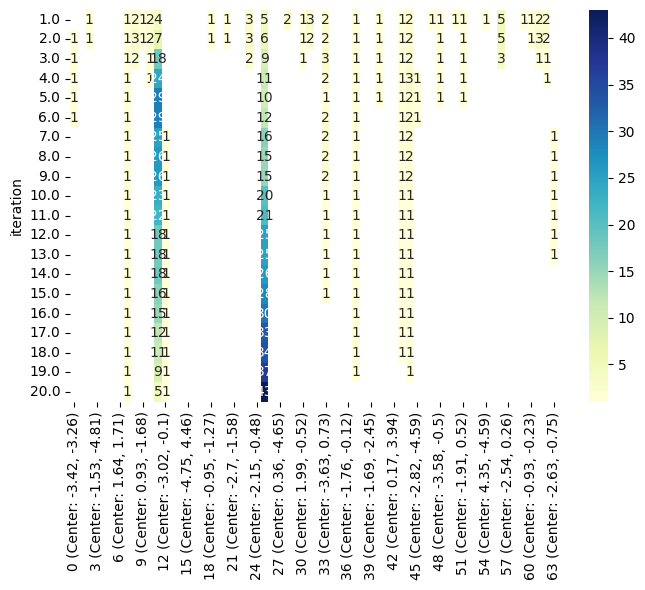

F15_I3 OriginalWOA 4
     iteration  cluster  scaled_raw_y
0          1.0        0      0.007539
1          1.0        2      0.002123
2          1.0        6      0.002123
3          1.0        9      0.002123
4          1.0       12      0.002123
..         ...      ...           ...
150       17.0        5      0.000910
151       17.0       12      0.000910
152       18.0        2      0.000910
153       19.0        2      0.000910
154       20.0        2      0.000910

[155 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


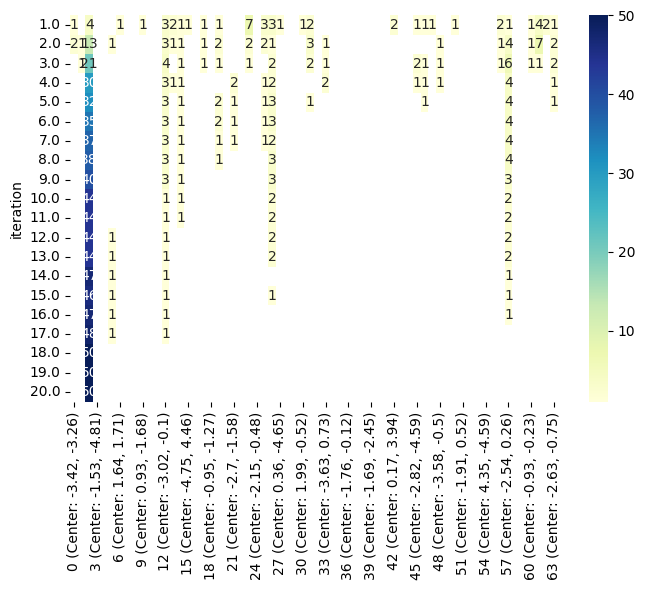

F15_I3 OriginalWOA 5
     iteration  cluster  scaled_raw_y
0          1.0        2      0.005949
1          1.0        8      0.005949
2          1.0       10      0.005949
3          1.0       13      0.005949
4          1.0       16      0.005610
..         ...      ...           ...
229       18.0       24      0.000182
230       19.0       14      0.000182
231       19.0       24      0.000182
232       20.0       14      0.000182
233       20.0       24      0.000182

[234 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


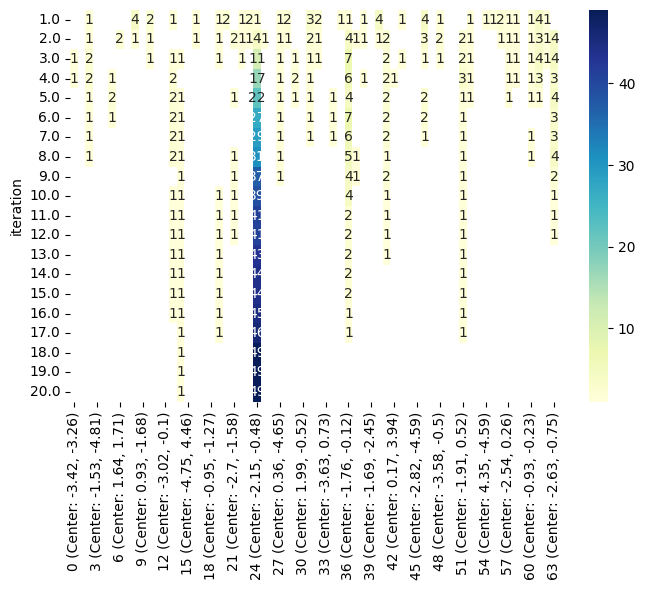

In [4]:
visualize([2], ['F15_I3'], ['HI_WOA','OriginalWOA'], [1,2,3,4, 5], data_dir=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init', plot_y=False)

               x0        x1
cluster                    
0        1.944266  1.388365
1       -3.752975 -4.995525
2       -0.148380  2.947343
3       -4.005169 -0.195007
4       -1.384229 -4.996716
5       -1.706582  2.574341
6        4.997424 -4.982298
7        4.999686  4.984489
8        0.981514 -4.997153
9       -0.018199 -5.000000
10       1.311965 -5.000000
11       0.648395 -5.000000
12       2.669701  4.999097
13       3.761231  0.801253
14      -4.417153 -4.995769
15      -4.190583 -2.619198
16      -5.000000 -3.446441
17      -1.116340 -1.228332
18       4.998521  3.072577
19      -1.731613 -0.279210
20       4.992975  0.363912
21      -3.441607 -4.992565
22       0.298165  4.998924
23       0.628491  4.999998
24      -0.367716  4.999294
25       1.962689  4.976558
26       0.959288  4.993530
27      -0.039390  4.997596
28      -3.217328  0.332966
29       0.970206 -2.799556
30       4.996752  1.477408
31      -4.099635 -4.997194
32      -4.956662  1.320757
33      -2.733770  4

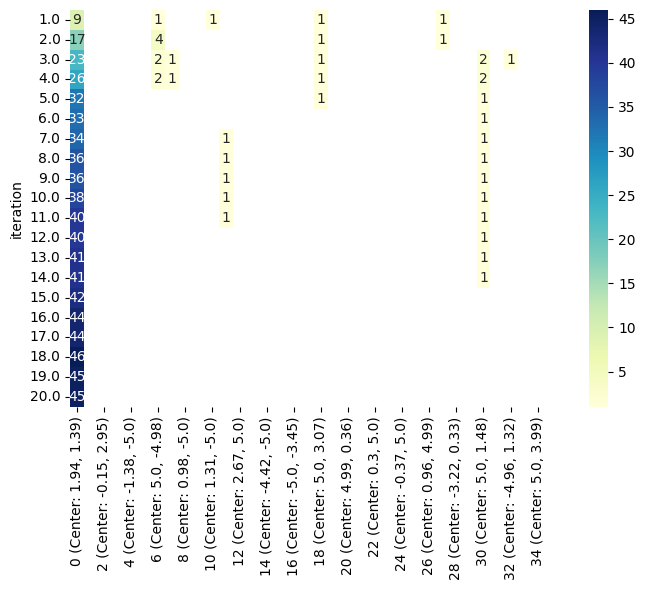

F23_I2 AugmentedAEO 2
     iteration  cluster  scaled_raw_y
0          1.0        6      0.385159
1          1.0        7      0.385159
2          1.0       21      0.264796
3          1.0       36      0.074792
4          2.0        2      0.024489
..         ...      ...           ...
100       20.0        2      0.012390
101       20.0        4      0.012390
102       20.0       21      0.012389
103       20.0       34      0.012389
104       20.0       36      0.012389

[105 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


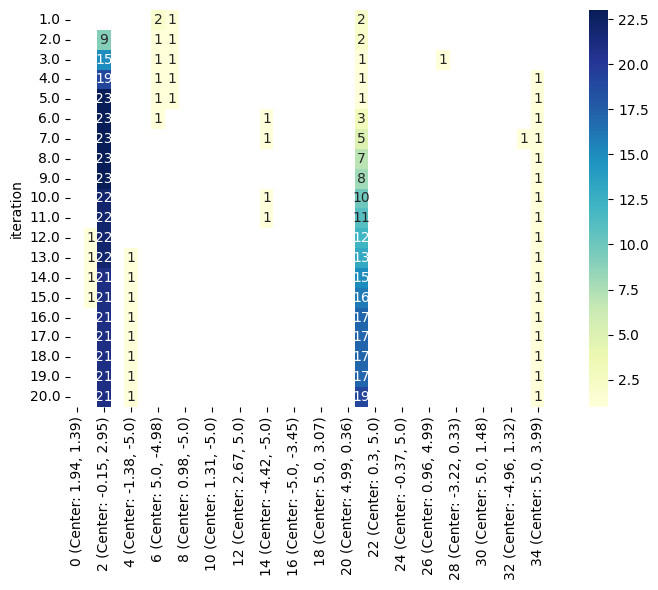

F23_I2 AugmentedAEO 3
    iteration  cluster  scaled_raw_y
0         1.0        6  3.851592e-01
1         1.0        7  3.851592e-01
2         1.0       12  2.030936e-01
3         1.0       13  4.913778e-03
4         1.0       30  4.913778e-03
..        ...      ...           ...
68       18.0       36  3.471024e-08
69       19.0       13  1.358130e-09
70       19.0       36  1.358130e-09
71       20.0       13  0.000000e+00
72       20.0       36  0.000000e+00

[73 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


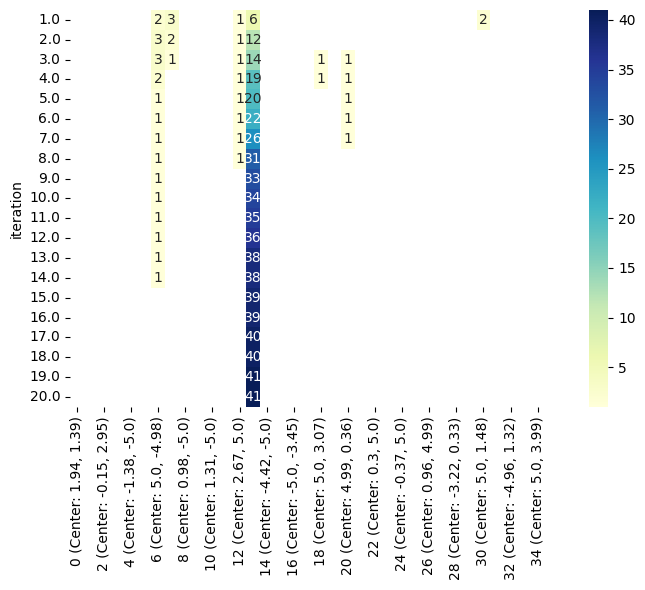

F23_I2 AugmentedAEO 4
    iteration  cluster  scaled_raw_y
0         1.0        3      0.018656
1         1.0        6      0.018656
2         1.0       27      0.018656
3         1.0       33      0.018656
4         1.0       36      0.018656
..        ...      ...           ...
56       19.0       33      0.000138
57       19.0       36      0.000138
58       20.0        3      0.000120
59       20.0       33      0.000120
60       20.0       36      0.000120

[61 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


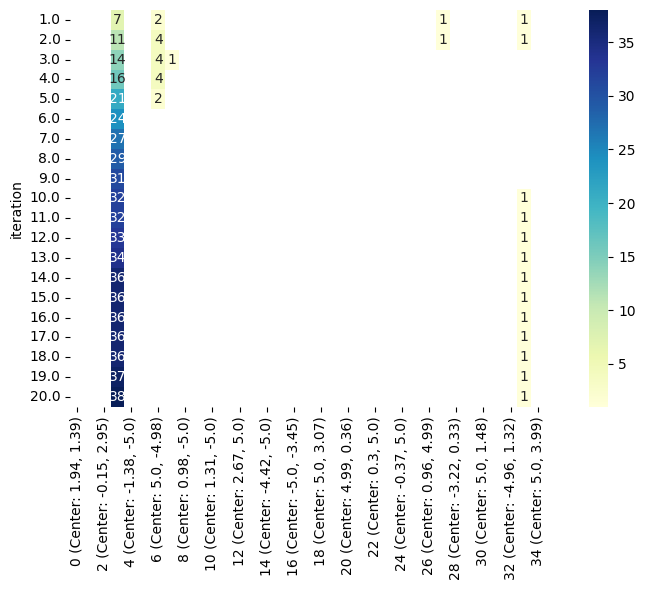

F23_I2 AugmentedAEO 5
    iteration  cluster  scaled_raw_y
0         1.0        6      0.385159
1         1.0        7      0.150268
2         1.0       20      0.078065
3         1.0       32      0.065123
4         1.0       36      0.065123
..        ...      ...           ...
57       19.0       14      0.000098
58       19.0       32      0.000071
59       19.0       36      0.000071
60       20.0       32      0.000042
61       20.0       36      0.000042

[62 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


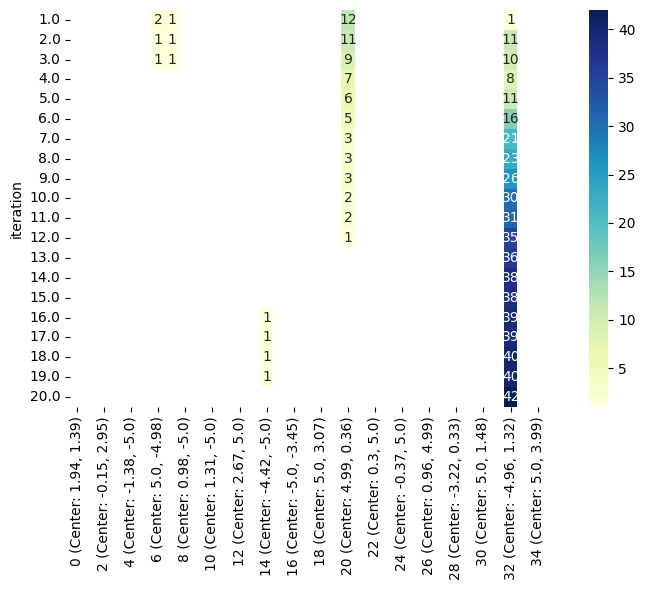

F23_I2 ModifiedAEO 1
    iteration  cluster  scaled_raw_y
0         1.0        6      0.385159
1         1.0        7      0.385159
2         1.0       18      0.073062
3         1.0       20      0.073062
4         1.0       34      0.073062
..        ...      ...           ...
92       19.0       34      0.011561
93       19.0       36      0.011561
94       20.0       18      0.011561
95       20.0       34      0.011561
96       20.0       36      0.011561

[97 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


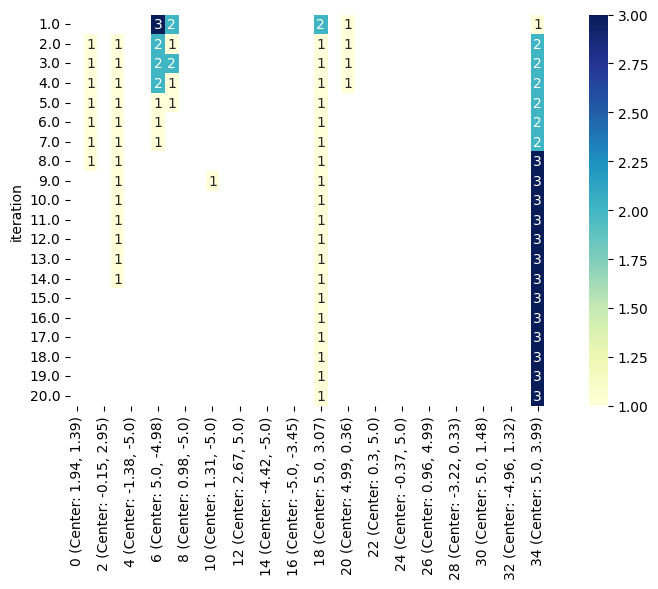

F23_I2 ModifiedAEO 2
     iteration  cluster  scaled_raw_y
0          1.0        7      0.391644
1          1.0       18      0.114102
2          1.0       34      0.026596
3          1.0       36      0.026596
4          2.0        7      0.026596
..         ...      ...           ...
138       20.0       16      0.001815
139       20.0       23      0.001815
140       20.0       31      0.001815
141       20.0       34      0.001815
142       20.0       36      0.001815

[143 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


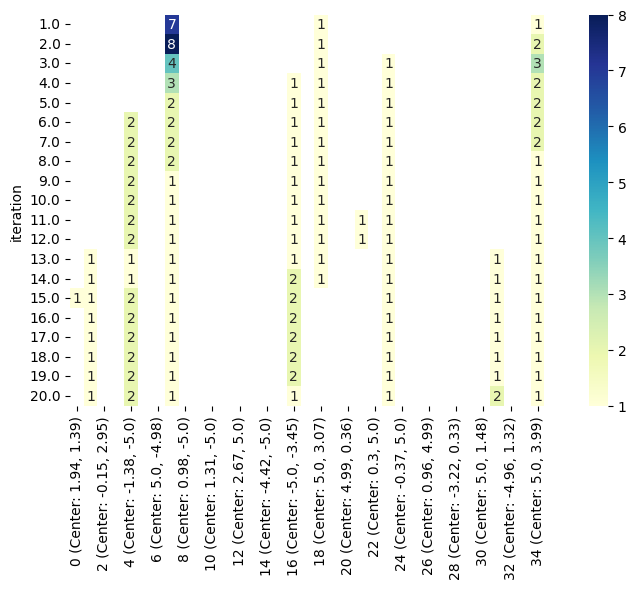

F23_I2 ModifiedAEO 3
     iteration  cluster  scaled_raw_y
0          1.0        6      0.385159
1          1.0        7      0.385159
2          1.0       14      0.125156
3          1.0       19      0.125156
4          1.0       31      0.043119
..         ...      ...           ...
123       20.0       14      0.005197
124       20.0       25      0.005197
125       20.0       31      0.005197
126       20.0       33      0.005197
127       20.0       36      0.005197

[128 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


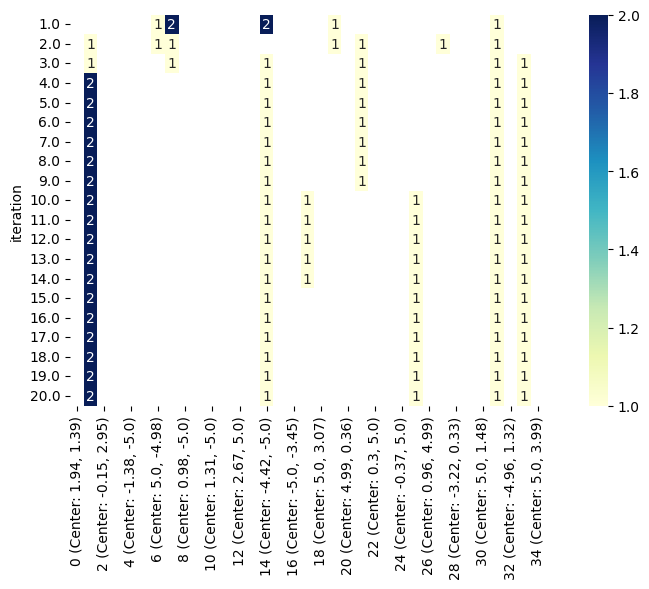

F23_I2 ModifiedAEO 4
    iteration  cluster  scaled_raw_y
0         1.0        6      0.385159
1         1.0       26      0.385159
2         1.0       36      0.034706
3         2.0        6      0.034706
4         2.0       36      0.034706
..        ...      ...           ...
65       19.0       36      0.010268
66       20.0       18      0.010268
67       20.0       22      0.010268
68       20.0       34      0.010268
69       20.0       36      0.010268

[70 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


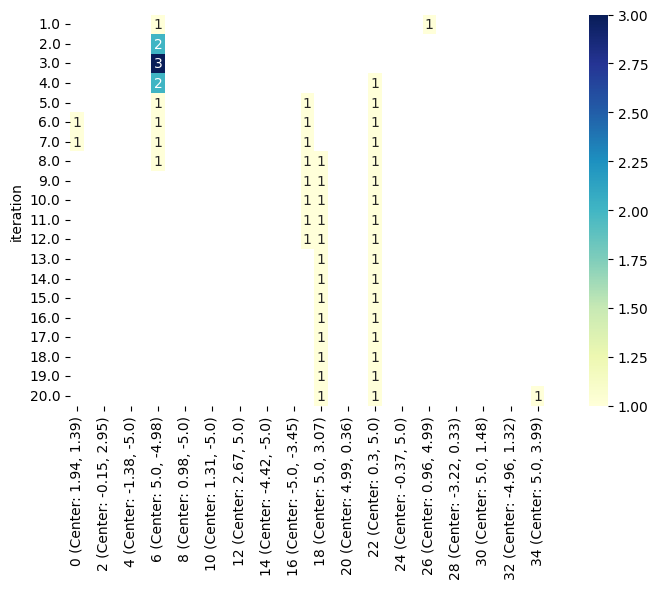

F23_I2 ModifiedAEO 5
    iteration  cluster  scaled_raw_y
0         1.0        4      0.072588
1         1.0        6      0.072588
2         1.0       36      0.026665
3         2.0        4      0.026665
4         2.0        6      0.026665
..        ...      ...           ...
60       19.0       36      0.013212
61       20.0        4      0.013212
62       20.0       10      0.013212
63       20.0       18      0.013212
64       20.0       36      0.013212

[65 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


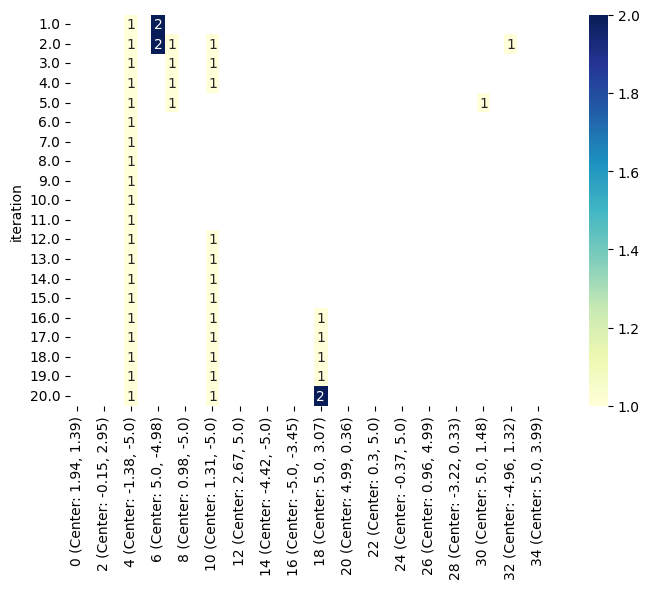

In [9]:
algorithms_of_interest=["ModifiedAEO",
"OriginalAEO",
"AugmentedAEO",
"OriginalSHADE",
"SADE",
"JADE",
"OriginalDE",
"OriginalWOA",
"HI_WOA"]

visualize([2], ['F23_I2'], ['AugmentedAEO', 'ModifiedAEO'], [1, 2, 3, 4, 5],data_dir=f'data/clustering_features_10_algorithms_dbscan', plot_y=False)

    scaled_x0  scaled_x1
0   -1.329093   1.428670
1   -4.538486  -3.480184
2   -3.782924   0.661374
3    2.279349  -0.159496
4   -2.166210  -0.380001
5    3.155546  -3.991431
6    0.576405   3.107079
7   -3.174017  -4.327252
8    4.569192   0.604639
9   -4.956394  -4.962658
10  -3.067228   0.898775
11  -1.503715   4.413642
12   0.177886  -0.997564
13  -4.290876   0.498781
14  -3.110208  -2.190902
15  -4.493786  -1.159633
16   2.070974   1.945983
17  -0.517095   2.816850
18  -3.450069   3.258853
19  -2.011726  -1.848942
20   3.955556   2.520626
21   0.853538   4.614357
22   1.090820  -3.885356
23   0.562975   1.983316
24  -1.042607  -1.444152
25  -4.881671  -4.488722
26  -4.918133   0.308651
27  -4.464575  -4.555865
28   3.521977   0.226478
29  -2.259128   1.133123
30  -0.347131   1.611885
31  -0.200310   4.110777
{0: '-1.33, 1.43', 1: '-4.54, -3.48', 2: '-3.78, 0.66', 3: '2.28, -0.16', 4: '-2.17, -0.38', 5: '3.16, -3.99', 6: '0.58, 3.11', 7: '-3.17, -4.33', 8: '4.57, 0.6', 9: '-4.96, -

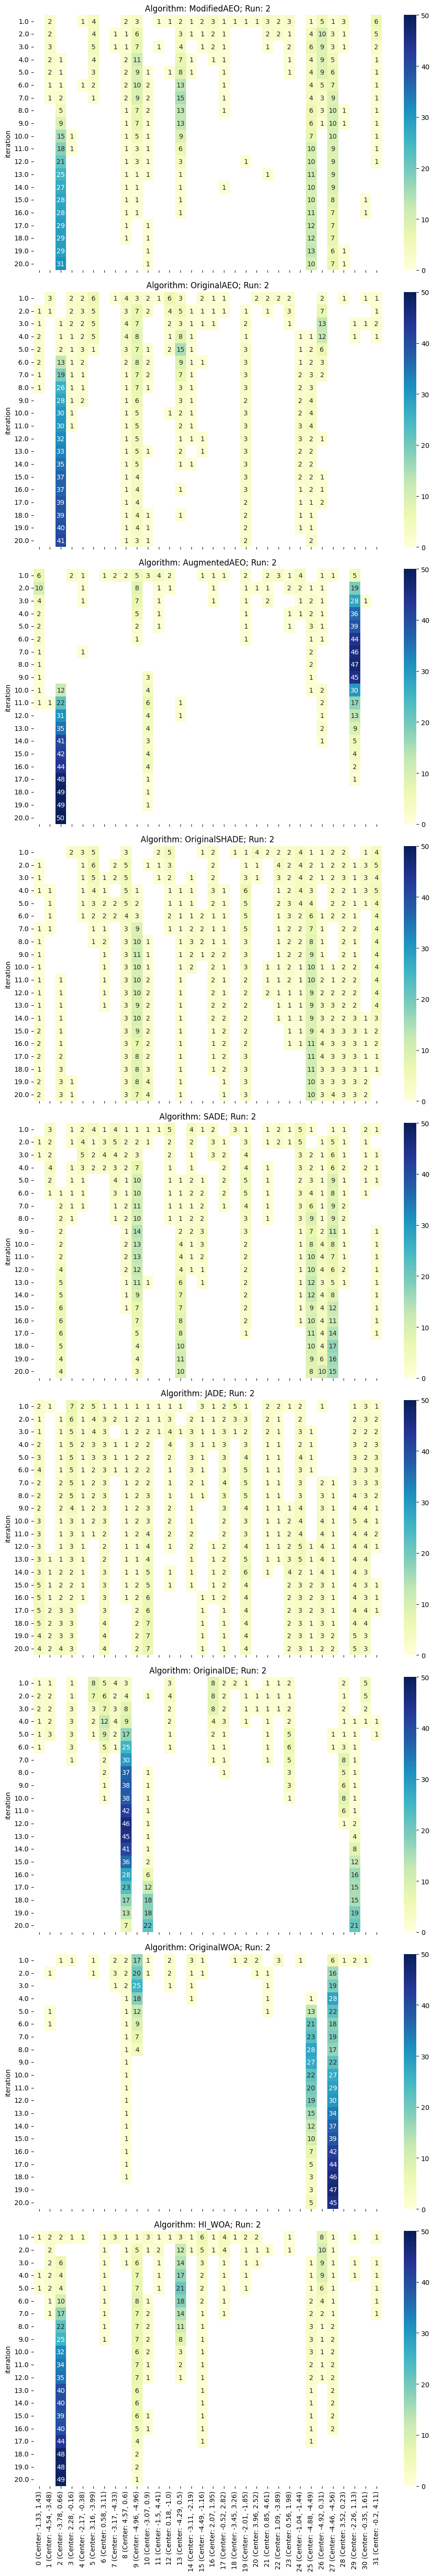

In [7]:
visualize_multi([2], ['F22_I4'], algorithms_of_interest, [2], data_dir=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init', save=False)

               x0        x1
cluster                    
0        1.729852 -0.107014
1       -2.108146 -4.064414
2        3.137685 -2.926323
3        3.013816 -2.712674
4        2.076122 -1.567749
5        0.342436  2.794042
6        0.196607  3.127413
7       -0.776240  4.990246
8       -0.468697  4.420479
9        3.695253  4.979582
10       1.372527 -3.863461
11       1.786065 -3.709730
{0: '1.73, -0.11', 1: '-2.11, -4.06', 2: '3.14, -2.93', 3: '3.01, -2.71', 4: '2.08, -1.57', 5: '0.34, 2.79', 6: '0.2, 3.13', 7: '-0.78, 4.99', 8: '-0.47, 4.42', 9: '3.7, 4.98', 10: '1.37, -3.86', 11: '1.79, -3.71'}
F22_I1 JADE 1
    iteration  cluster  scaled_raw_y
0         1.0        0      0.000695
1         1.0        1      0.000695
2         1.0       12      0.000695
3         2.0        0      0.000695
4         2.0        1      0.000695
..        ...      ...           ...
67       19.0        1      0.000028
68       19.0       12      0.000028
69       20.0        0      0.000028
70       

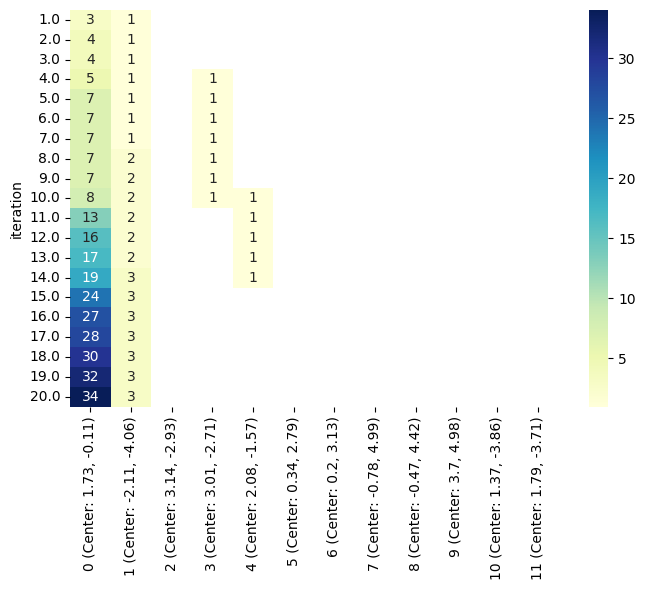

F22_I1 JADE 2
    iteration  cluster  scaled_raw_y
0         1.0        0  1.448633e-04
1         1.0       12  1.448633e-04
2         2.0        0  1.448633e-04
3         2.0       12  1.448633e-04
4         3.0        0  3.646967e-05
5         3.0       12  3.646967e-05
6         4.0        0  3.646967e-05
7         4.0       12  3.646967e-05
8         5.0        0  3.646967e-05
9         5.0        4  3.646967e-05
10        5.0       12  3.646967e-05
11        6.0        0  2.936462e-07
12        6.0        4  2.936462e-07
13        6.0       12  2.936462e-07
14        7.0        0  2.936462e-07
15        7.0        4  2.936462e-07
16        7.0       12  2.936462e-07
17        8.0        0  2.936462e-07
18        8.0        4  2.936462e-07
19        8.0       12  2.936462e-07
20        9.0        0  2.936462e-07
21        9.0        4  2.936462e-07
22        9.0       12  2.936462e-07
23       10.0        0  2.936462e-07
24       10.0        4  2.936462e-07
25       10.0       12  

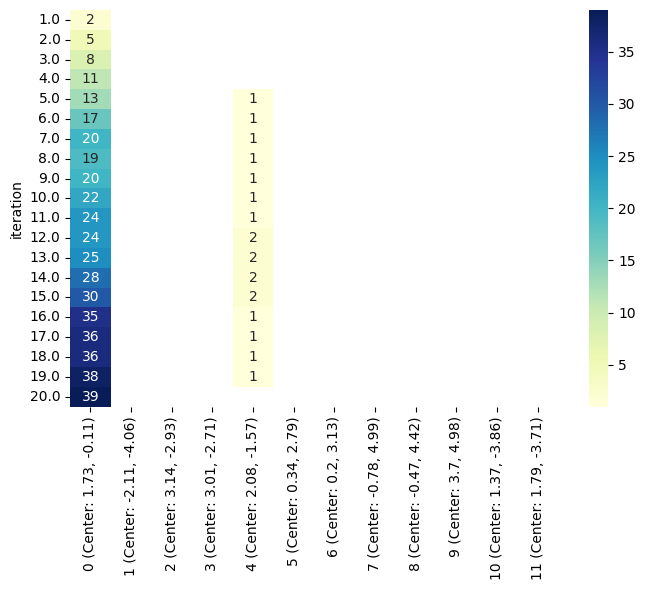

F22_I1 JADE 3
     iteration  cluster  scaled_raw_y
0          1.0       12  1.664504e-02
1          2.0        0  1.664504e-02
2          2.0       12  1.664504e-02
3          3.0        0  9.735603e-04
4          3.0       12  9.735603e-04
..         ...      ...           ...
96        20.0        4  5.226475e-07
97        20.0        6  5.226475e-07
98        20.0        8  5.226475e-07
99        20.0       11  5.226475e-07
100       20.0       12  5.226475e-07

[101 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


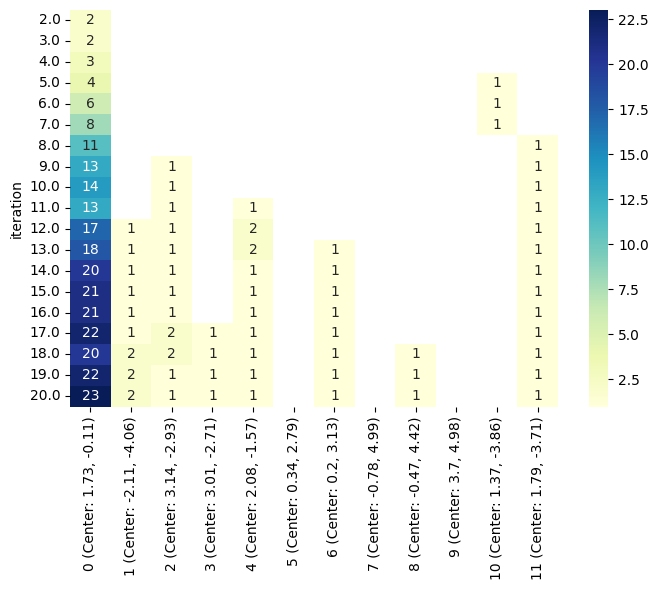

F22_I1 SADE 1
    iteration  cluster  scaled_raw_y
0         1.0        0  5.562651e-03
1         1.0        1  5.562651e-03
2         1.0       12  5.562651e-03
3         2.0        0  5.562651e-03
4         2.0        5  5.562651e-03
..        ...      ...           ...
75       19.0       12  8.971728e-07
76       20.0        0  8.971728e-07
77       20.0        4  8.971728e-07
78       20.0        7  8.971728e-07
79       20.0       12  8.971728e-07

[80 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


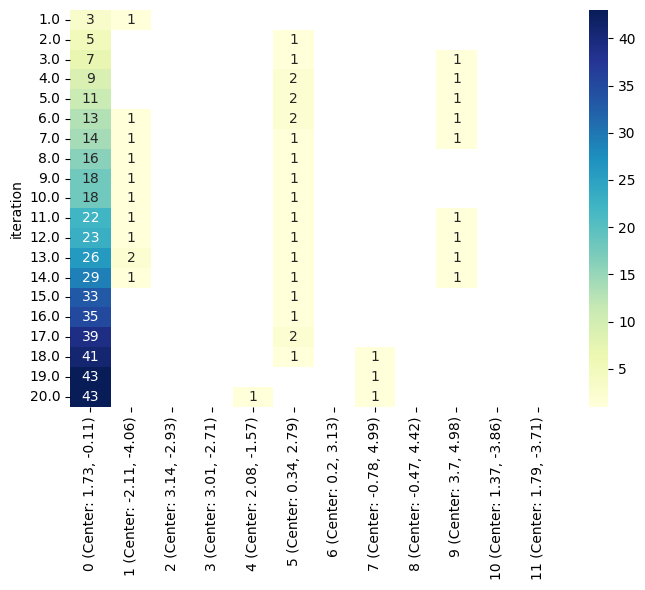

F22_I1 SADE 2
     iteration  cluster  scaled_raw_y
0          1.0        0      0.005585
1          1.0        5      0.005157
2          1.0       12      0.005157
3          2.0        0      0.001835
4          2.0        5      0.001835
..         ...      ...           ...
97        19.0       12      0.000001
98        20.0        0      0.000001
99        20.0        1      0.000001
100       20.0        2      0.000001
101       20.0       12      0.000001

[102 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


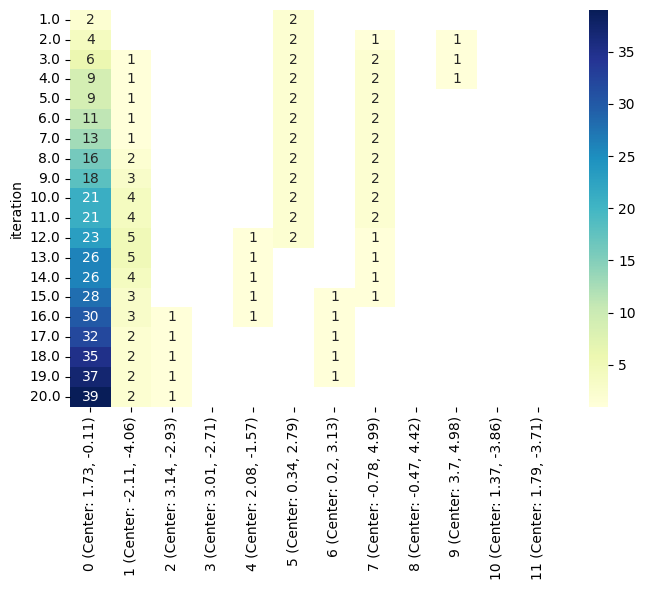

F22_I1 SADE 3
     iteration  cluster  scaled_raw_y
0          1.0        0  1.147716e-02
1          1.0        1  1.147716e-02
2          1.0       12  1.147716e-02
3          2.0        0  1.902050e-06
4          2.0        5  1.902050e-06
..         ...      ...           ...
96        20.0        1  5.236849e-07
97        20.0        5  5.236849e-07
98        20.0        6  5.236849e-07
99        20.0        8  5.236849e-07
100       20.0       12  5.236849e-07

[101 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


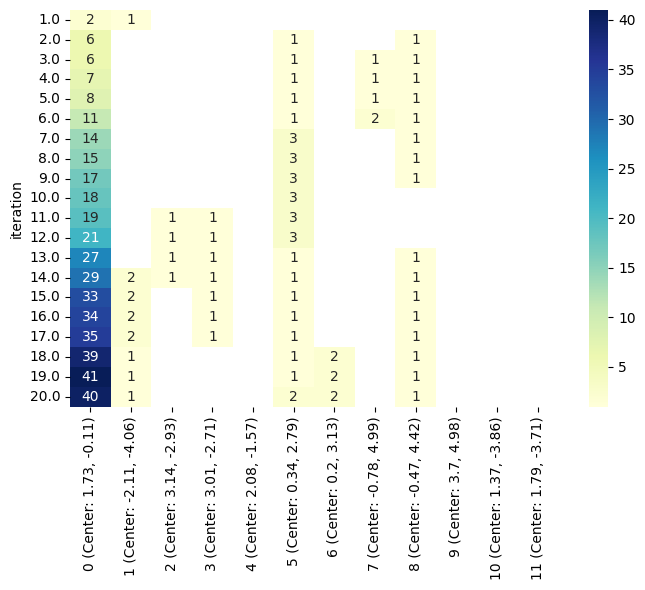

In [12]:
visualize([2], ['F22_I1'], ['JADE','SADE'], [1,2,3],data_dir=f'data/clustering_features_10_algorithms_dbscan', plot_y=False)

               x0        x1
cluster                    
0        1.729852 -0.107014
1       -2.108146 -4.064414
2        3.137685 -2.926323
3        3.013816 -2.712674
4        2.076122 -1.567749
5        0.342436  2.794042
6        0.196607  3.127413
7       -0.776240  4.990246
8       -0.468697  4.420479
9        3.695253  4.979582
10       1.372527 -3.863461
11       1.786065 -3.709730
{0: '1.73, -0.11', 1: '-2.11, -4.06', 2: '3.14, -2.93', 3: '3.01, -2.71', 4: '2.08, -1.57', 5: '0.34, 2.79', 6: '0.2, 3.13', 7: '-0.78, 4.99', 8: '-0.47, 4.42', 9: '3.7, 4.98', 10: '1.37, -3.86', 11: '1.79, -3.71'}
F22_I1 JADE 1
    iteration  cluster  scaled_raw_y
0         1.0        0      0.000695
1         1.0        1      0.000695
2         1.0       12      0.000695
3         2.0        0      0.000695
4         2.0        1      0.000695
..        ...      ...           ...
67       19.0        1      0.000028
68       19.0       12      0.000028
69       20.0        0      0.000028
70       

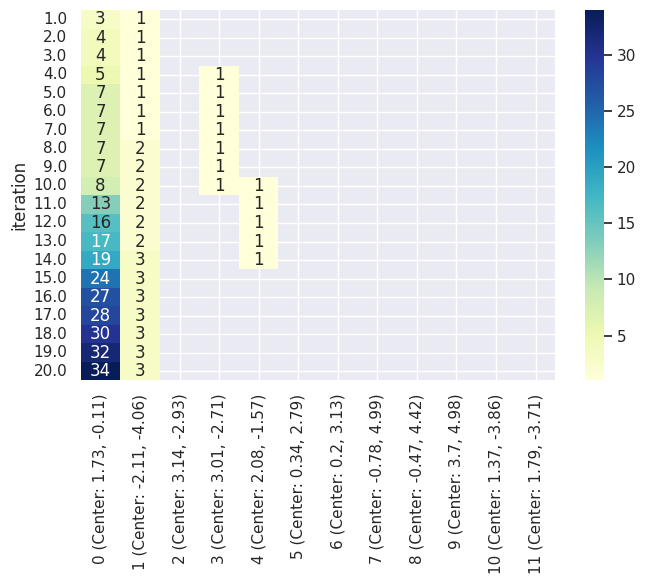

F22_I1 JADE 2
    iteration  cluster  scaled_raw_y
0         1.0        0  1.448633e-04
1         1.0       12  1.448633e-04
2         2.0        0  1.448633e-04
3         2.0       12  1.448633e-04
4         3.0        0  3.646967e-05
5         3.0       12  3.646967e-05
6         4.0        0  3.646967e-05
7         4.0       12  3.646967e-05
8         5.0        0  3.646967e-05
9         5.0        4  3.646967e-05
10        5.0       12  3.646967e-05
11        6.0        0  2.936462e-07
12        6.0        4  2.936462e-07
13        6.0       12  2.936462e-07
14        7.0        0  2.936462e-07
15        7.0        4  2.936462e-07
16        7.0       12  2.936462e-07
17        8.0        0  2.936462e-07
18        8.0        4  2.936462e-07
19        8.0       12  2.936462e-07
20        9.0        0  2.936462e-07
21        9.0        4  2.936462e-07
22        9.0       12  2.936462e-07
23       10.0        0  2.936462e-07
24       10.0        4  2.936462e-07
25       10.0       12  

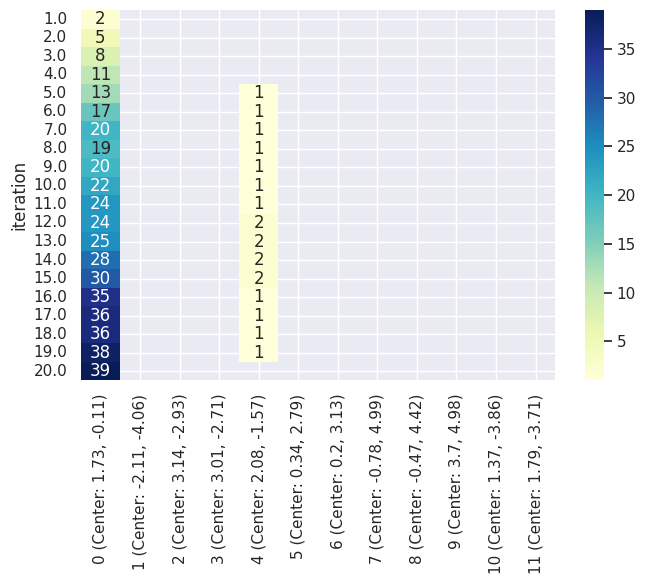

F22_I1 JADE 3
     iteration  cluster  scaled_raw_y
0          1.0       12  1.664504e-02
1          2.0        0  1.664504e-02
2          2.0       12  1.664504e-02
3          3.0        0  9.735603e-04
4          3.0       12  9.735603e-04
..         ...      ...           ...
96        20.0        4  5.226475e-07
97        20.0        6  5.226475e-07
98        20.0        8  5.226475e-07
99        20.0       11  5.226475e-07
100       20.0       12  5.226475e-07

[101 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


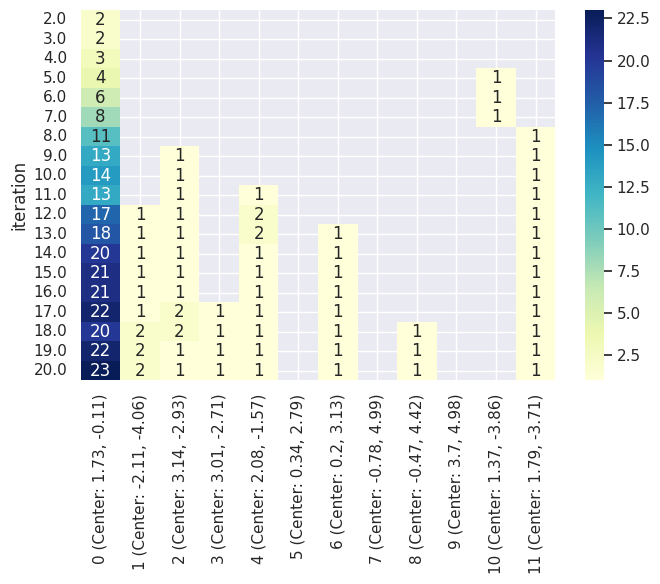

F22_I1 SADE 1
    iteration  cluster  scaled_raw_y
0         1.0        0  5.562651e-03
1         1.0        1  5.562651e-03
2         1.0       12  5.562651e-03
3         2.0        0  5.562651e-03
4         2.0        5  5.562651e-03
..        ...      ...           ...
75       19.0       12  8.971728e-07
76       20.0        0  8.971728e-07
77       20.0        4  8.971728e-07
78       20.0        7  8.971728e-07
79       20.0       12  8.971728e-07

[80 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


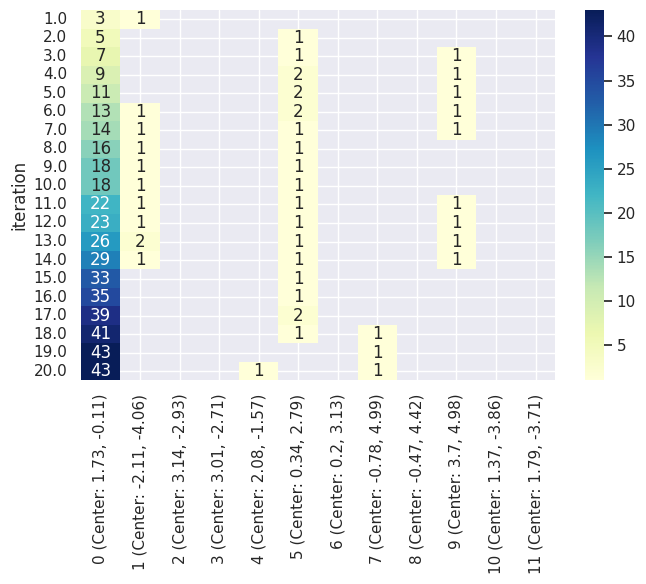

F22_I1 SADE 2
     iteration  cluster  scaled_raw_y
0          1.0        0      0.005585
1          1.0        5      0.005157
2          1.0       12      0.005157
3          2.0        0      0.001835
4          2.0        5      0.001835
..         ...      ...           ...
97        19.0       12      0.000001
98        20.0        0      0.000001
99        20.0        1      0.000001
100       20.0        2      0.000001
101       20.0       12      0.000001

[102 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


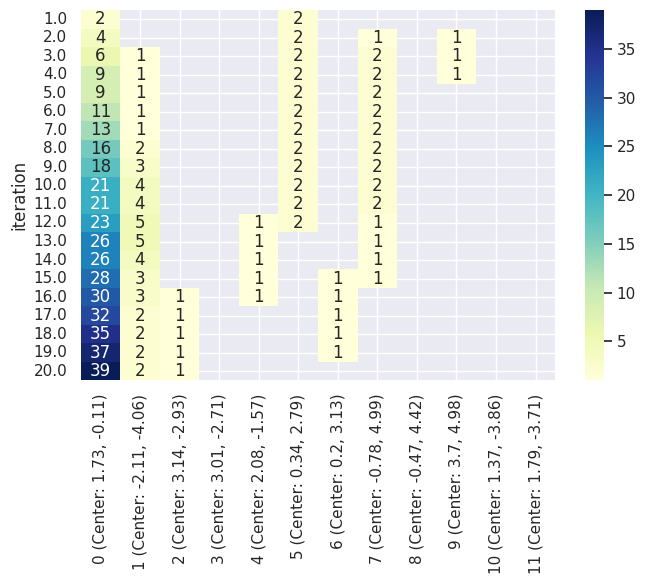

F22_I1 SADE 3
     iteration  cluster  scaled_raw_y
0          1.0        0  1.147716e-02
1          1.0        1  1.147716e-02
2          1.0       12  1.147716e-02
3          2.0        0  1.902050e-06
4          2.0        5  1.902050e-06
..         ...      ...           ...
96        20.0        1  5.236849e-07
97        20.0        5  5.236849e-07
98        20.0        6  5.236849e-07
99        20.0        8  5.236849e-07
100       20.0       12  5.236849e-07

[101 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


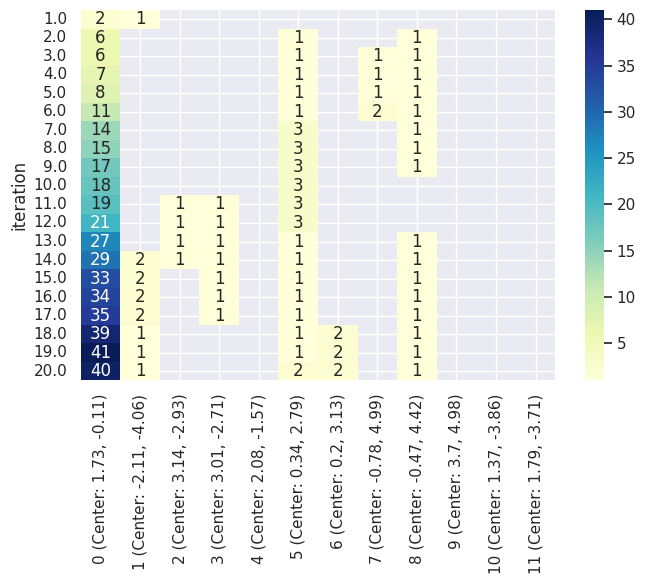

In [ ]:
visualize([2], ['F22_I1'], ['JADE','SADE'], [1,2,3],data_dir=f'data/clustering_features_10_algorithms_dbscan', plot_y=False)

In [13]:
dimension=2
directory=f'data/clustering_features_10_algorithms_dbscan/cluster_distributions/dim_{dimension}/eps0.1_ms150'

trajectory_similarities=[]
for file in tqdm(os.listdir(directory)):
    file_loc=f'{directory}/{file}'
    if os.path.isfile(file_loc):
        df=pd.read_csv(file_loc,index_col=[0,1,2])
        d_algorithm_run=df.unstack(level=-1).dropna()
        #d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
        cs=pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
        c=cs.reset_index().rename(columns={'algorithm':'algorithm2', 'run':'run2'}).melt(id_vars=[('algorithm2',  ''),('run2',  '')], value_vars=list(cs.columns)).rename(columns={('algorithm2',  ''): 'algorithm2', ('run2',''):'run2'})
        trajectory_similarities+=[c.assign(problem=file.replace('.csv',''))]

trajectory_similarities=pd.concat(trajectory_similarities)
#t=trajectory_similarities.groupby('algorithm').count()['run']
#t_max=t.max()
#algorithms_to_remove=list(t[t<t_max].index)
#trajectory_similarities=trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
trajectory_similarities['problem_class']=[int(tt.split('_')[0].replace('F','')) for tt in trajectory_similarities['problem']]
trajectory_similarities['instance']=[int(tt.split('_')[1].replace('I','')) for tt in trajectory_similarities['problem']]
trajectory_similarities['run'] = trajectory_similarities['run'].astype(int)
trajectory_similarities['run2'] = trajectory_similarities['run2'].astype(int)

100%|██████████| 120/120 [00:01<00:00, 100.27it/s]


In [14]:
trajectory_similarities.query('algorithm!=algorithm2').sort_values('value')

,algorithm2,run2,algorithm,run,value,problem,problem_class,instance
24,OriginalDE,2,AugmentedAEO,1,0.000000,F21_I5,21,5
251,OriginalDE,2,HI_WOA,1,0.000000,F16_I2,16,2
369,AugmentedAEO,1,HI_WOA,5,0.000000,F24_I4,24,4
250,OriginalDE,1,HI_WOA,1,0.000000,F16_I2,16,2
235,JADE,1,HI_WOA,1,0.000000,F16_I2,16,2
...,...,...,...,...,...,...,...,...
239,OriginalWOA,3,HI_WOA,1,0.999906,F14_I2,14,2
812,ModifiedAEO,2,OriginalAEO,4,0.999925,F5_I1,5,1
553,OriginalAEO,4,ModifiedAEO,2,0.999925,F5_I1,5,1
101,OriginalAEO,5,AugmentedAEO,3,0.999929,F5_I3,5,3


100%|██████████| 120/120 [00:01<00:00, 77.50it/s]


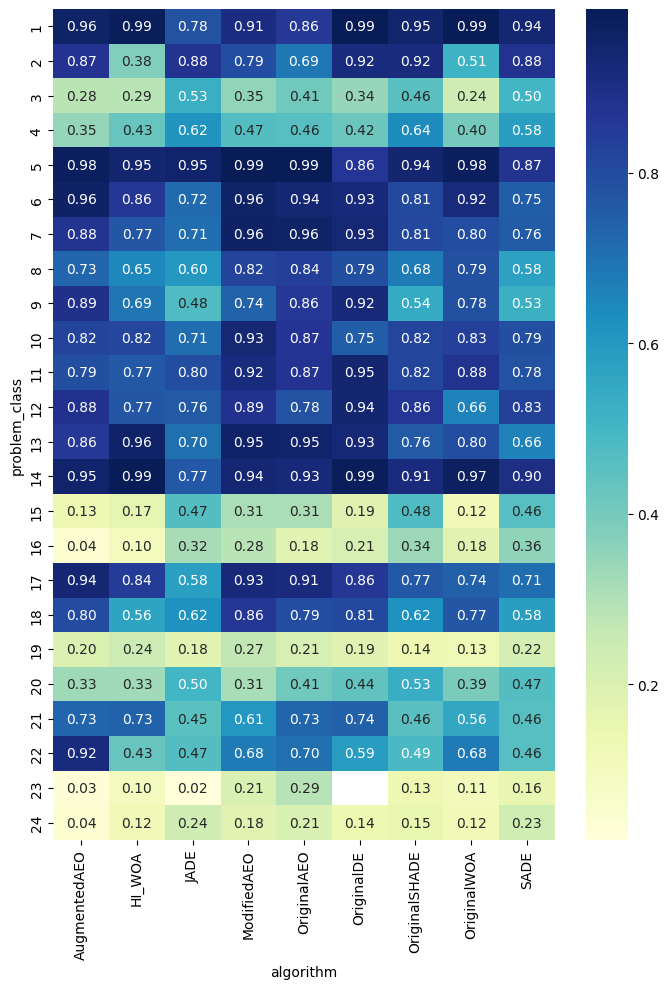

<Figure size 600x600 with 0 Axes>

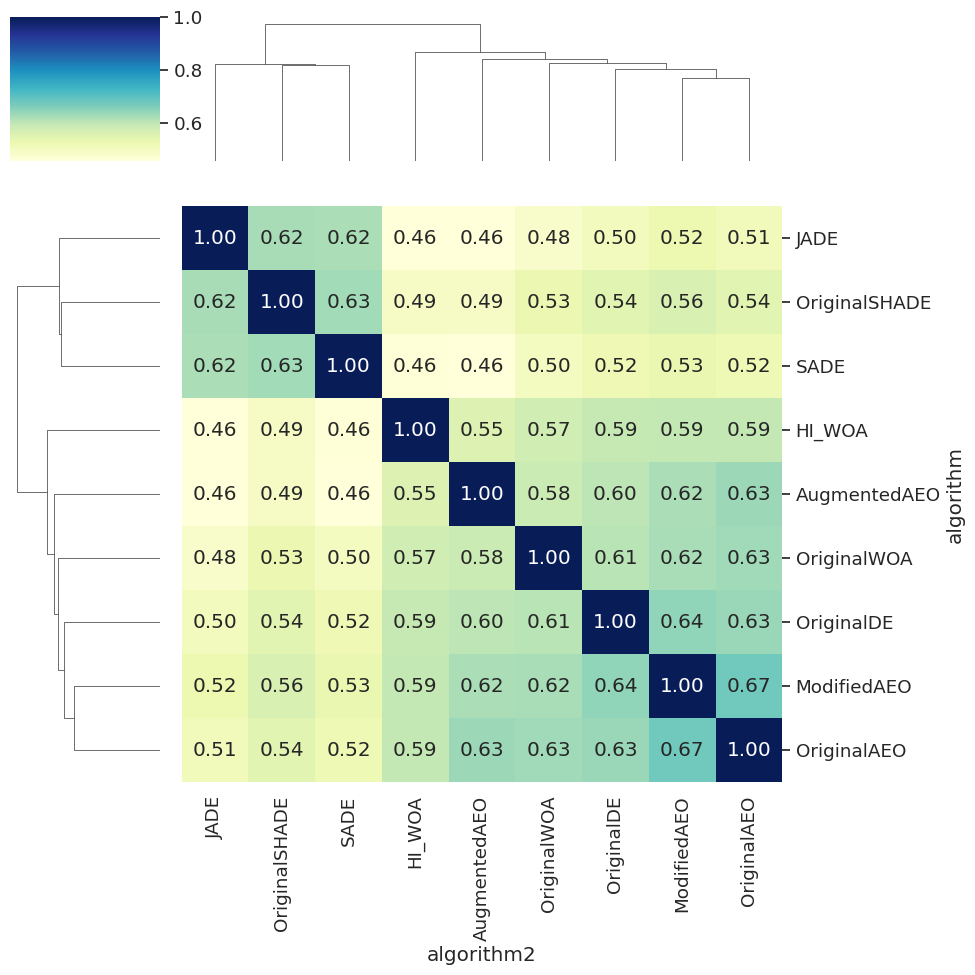

In [15]:
for dimension in [2]:
    directory=f'data/clustering_features_10_algorithms_dbscan/cluster_distributions/dim_{dimension}/eps0.1_ms150'
    scale=False
    trajectory_similarities=[]
    for file in tqdm(os.listdir(directory)):
        file_loc=f'{directory}/{file}'
        if os.path.isfile(file_loc):
            df=pd.read_csv(file_loc,index_col=[0,1,2])
            d_algorithm_run=df.unstack(level=-1).dropna()
            d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
            cs=pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
            c=cs.reset_index().rename(columns={'algorithm':'algorithm2', 'run':'run2'}).melt(id_vars=[('algorithm2',  ''),('run2',  '')], value_vars=list(cs.columns)).rename(columns={('algorithm2',  ''): 'algorithm2', ('run2',''):'run2'})
            trajectory_similarities+=[c.assign(problem=file.replace('.csv',''))]
    
    trajectory_similarities=pd.concat(trajectory_similarities)
    #t=trajectory_similarities.groupby('algorithm').count()['run']
    #t_max=t.max()
    #algorithms_to_remove=list(t[t<t_max].index)
    #trajectory_similarities=trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
    trajectory_similarities['problem_class']=[int(tt.split('_')[0].replace('F','')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['instance']=[int(tt.split('_')[1].replace('I','')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['run'] = trajectory_similarities['run'].astype(int)
    trajectory_similarities['run2'] = trajectory_similarities['run2'].astype(int)

    plt.figure(figsize=(7,10))
    sim_per_problem_algorithm=trajectory_similarities.query('algorithm==algorithm2 and run!=run2').groupby(['problem_class','algorithm'])['value'].mean()
    sns.heatmap(sim_per_problem_algorithm.reset_index().pivot(index='problem_class',columns='algorithm',values='value').sort_index(),annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new_dbscan/algorithm_similarity_per_problem_dim_{dimension}_scale_{scale}.pdf')

    cross_algorithm_similarity=trajectory_similarities.query('run==run2').groupby(['algorithm','algorithm2'])['value'].mean()
    cross_algorithm_similarity_pivoted=cross_algorithm_similarity.reset_index().pivot(index='algorithm',columns='algorithm2',values='value')
    sns.set_theme(font_scale=1.2)
    plt.figure(figsize=(6,6))
    sns.clustermap(cross_algorithm_similarity_pivoted,annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new_dbscan/algorithm_mean_similarity_clustermap_dim_{dimension}_scale_{scale}.pdf')
    sns.set_theme(font_scale=1)


In [16]:
optimizer_group=get_algorithm_groups()


In [17]:
cross_algorithm_similarity_to_save=cross_algorithm_similarity.reset_index()
cross_algorithm_similarity_to_save['algorithm_group']=cross_algorithm_similarity_to_save['algorithm'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save['algorithm2_group']=cross_algorithm_similarity_to_save['algorithm2'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save.sort_values('value',ascending=False).query('algorithm!=algorithm2').to_csv(f'data/clustering_features_10_algorithms_dbscan/algorithm_pairwise_similarity/algorithm_mean_similarity_{dimension}D.csv')

In [18]:

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

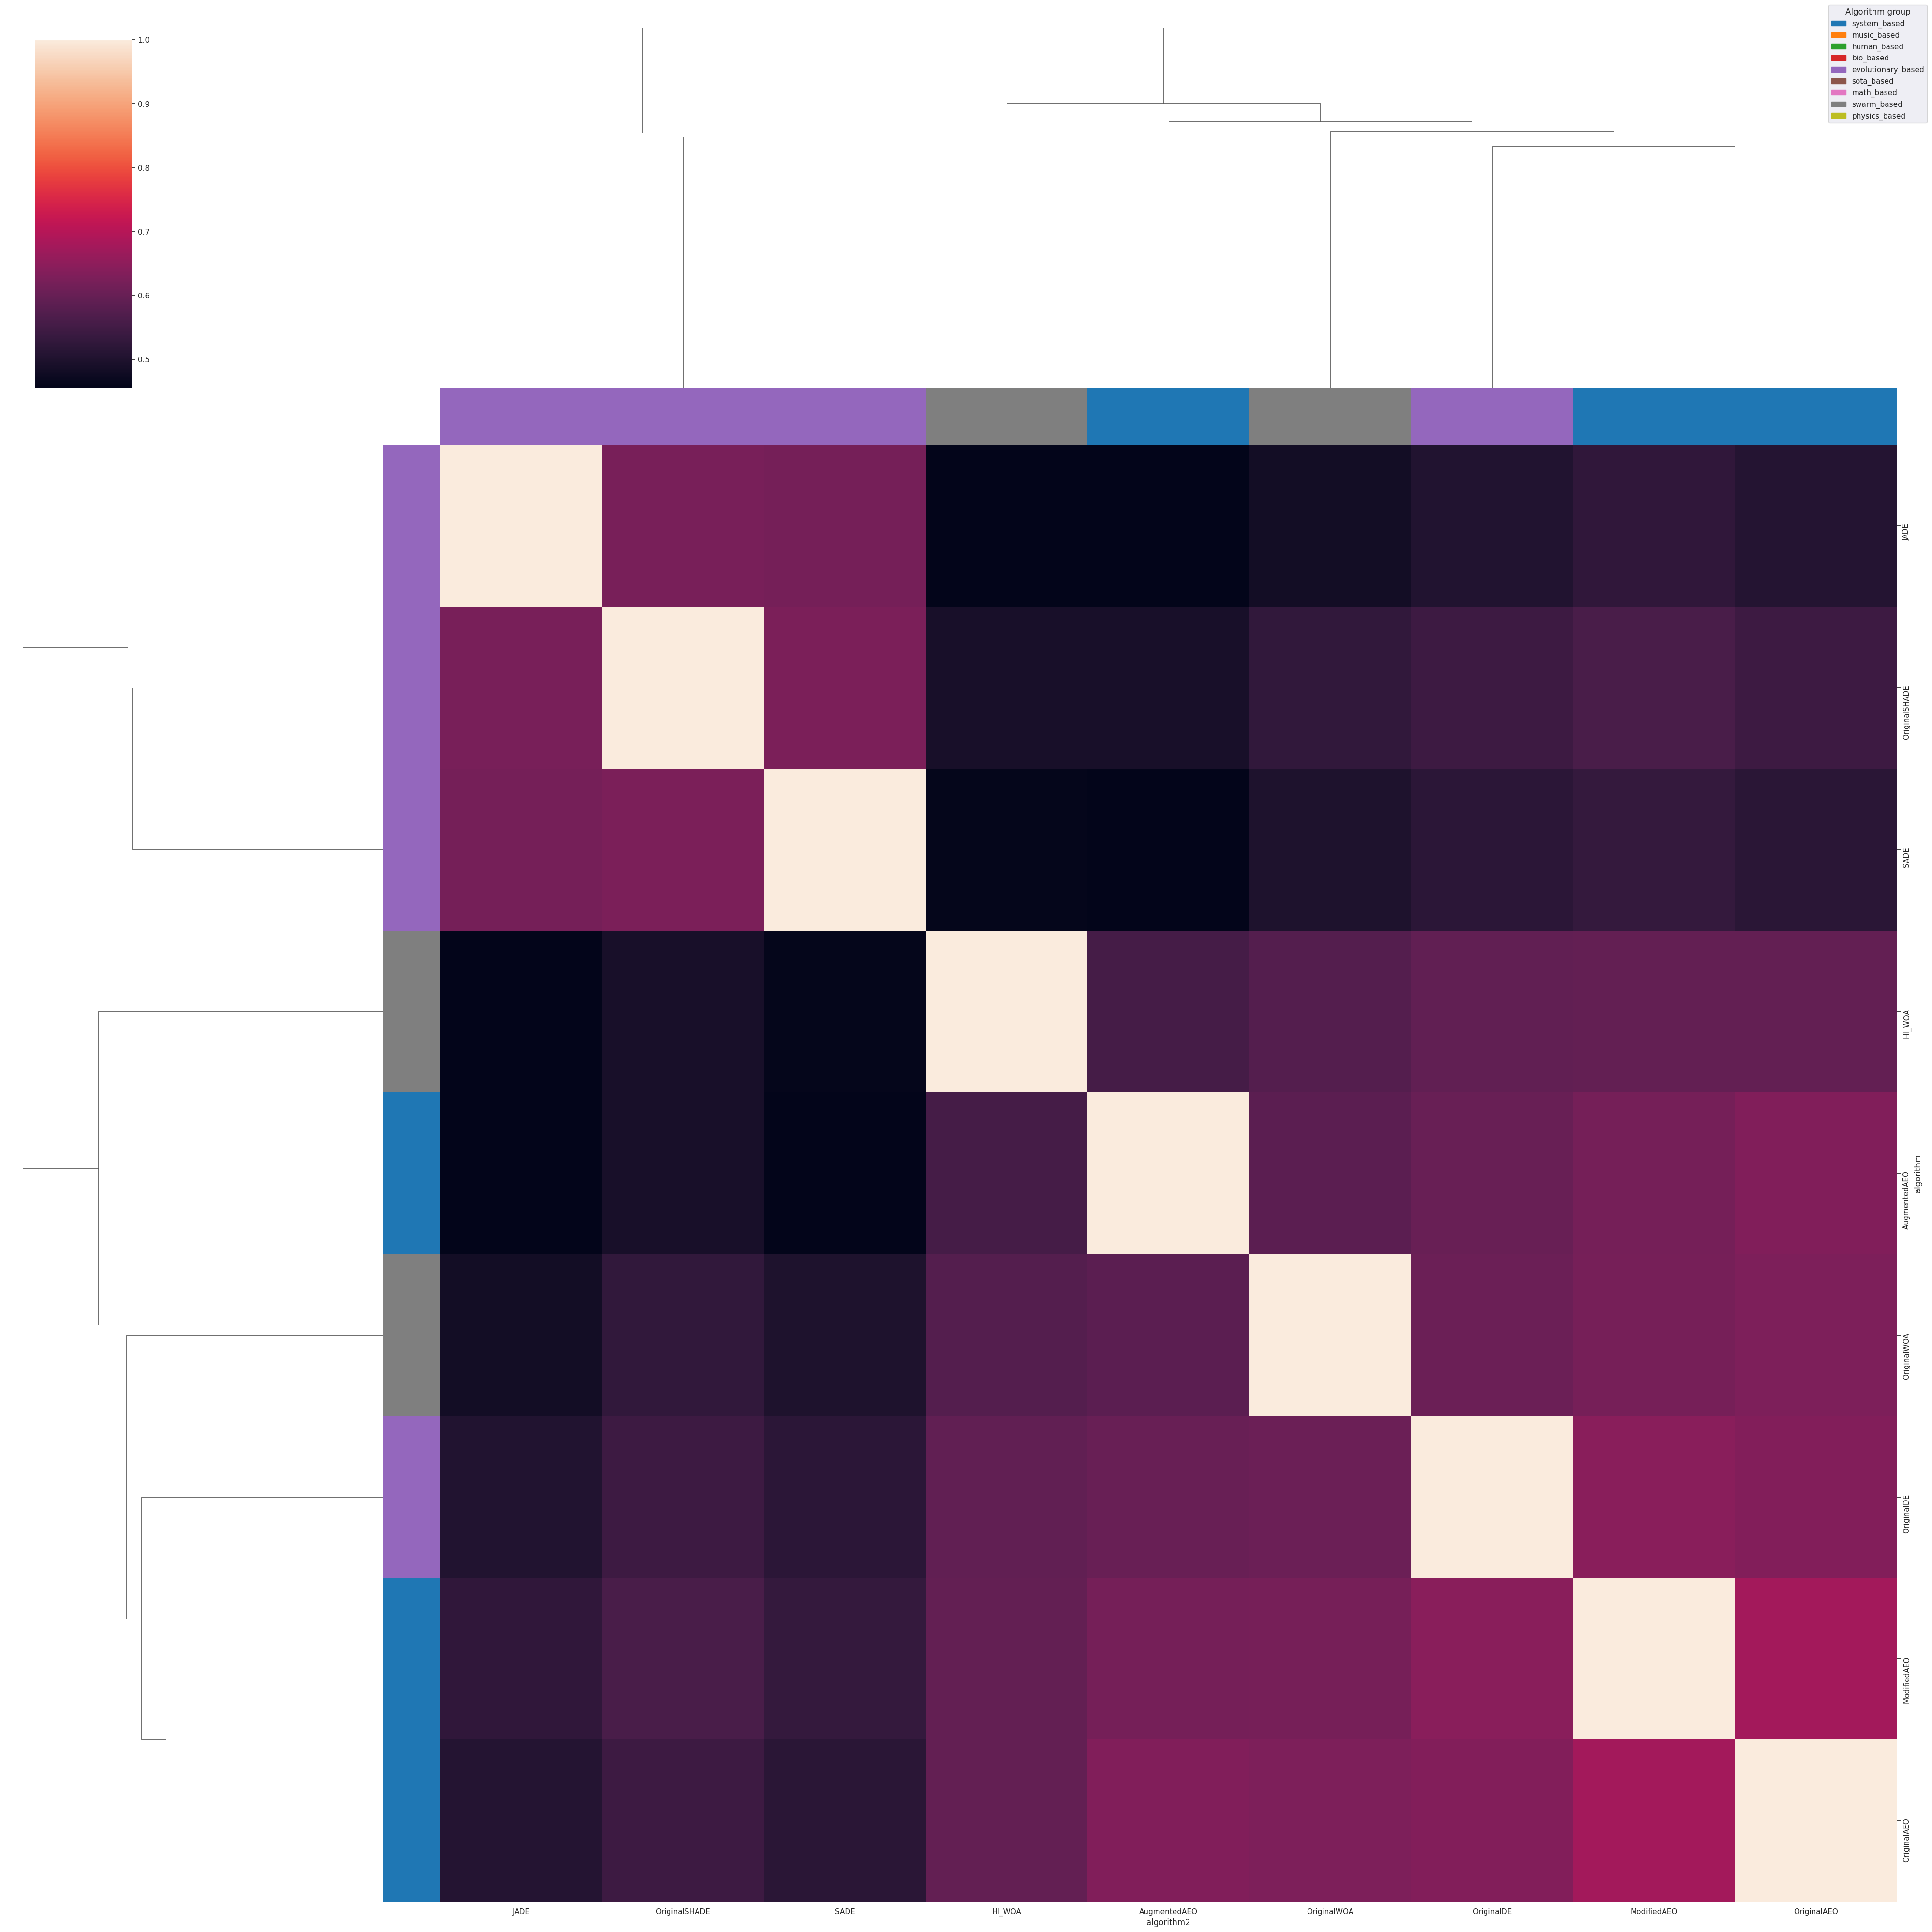

In [19]:
row_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.index]
col_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.columns]
sns.clustermap(cross_algorithm_similarity_pivoted, row_colors=row_colors, col_colors=col_colors,figsize=(40,40))
handles = [mpatches.Patch(color=color, label=label) for label, color in group_color.items()]
# Add legend to the clustermap
plt.legend(handles=handles, title='Algorithm group', bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure)

plt.savefig(f'figures_clustering_dbscan/algorithm_mean_similarity_clustermap_dim{dimension}.pdf')
#plt.show()
